# Аналіз e-commerce платформи Olist (Бразилія)

## Мета проєкту
Дослідити поведінку клієнтів та ефективність продажів бразильської онлайн-платформи Olist на основі 100 тис. реальних замовлень за 2016–2018 рр. і сформулювати практичні рекомендації для бізнесу.

## Дані
- **Джерело:** Brazilian E-Commerce Public Dataset by Olist (Kaggle)
- **Обсяг:** 100 000 замовлень, 9 пов'язаних таблиць (замовлення, товари, клієнти, платежі, відгуки та ін.)
- **Період:** 2016–2018
- **Формат:** CSV

## Інструменти
- **SQL (BigQuery)** - об'єднання таблиць та агрегації
- **Python** (pandas, matplotlib, seaborn, scipy) - чистка даних, статистика, візуалізації

## Аналітичні питання
1. Як змінювались виручка й кількість замовлень по місяцях?
2. Які категорії товарів дають найбільше виручки та замовлень?
3. Як регіон (штат) впливає на обсяг продажів і середній чек?
4. Який середній час доставки і як він пов'язаний з оцінками клієнтів?
5. Які способи оплати найпопулярніші і чи різниться середній чек між ними?
6. Яка частка повторних покупців і як виглядає утримання по когортах?
7. Чи є статистично значуща різниця в оцінках між швидкою й повільною доставкою?
8. Які фактори найбільше корелюють з негативними відгуками?

## 1. Підключення до даних

Завантажуємо набір даних Olist напряму з Kaggle через API. Ключ доступу зберігається в захищених секретах Colab, тому не з'являється у коді.

In [1]:
# НАЛАШТУВАННЯ ТА ЗАВАНТАЖЕННЯ ДАНИХ
import os, glob
import pandas as pd
from google.colab import userdata

# Ключ Kaggle із захищених секретів Colab
os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')
os.environ['KAGGLE_KEY'] = userdata.get('KAGGLE_KEY')

# Встановлюємо бібліотеку Kaggle і завантажуємо датасет Olist
!pip install -q kaggle
!kaggle datasets download -d olistbr/brazilian-ecommerce
!unzip -o -q '*.zip' -d olist_data

# Зчитуємо всі CSV-таблиці у словник dfs
dfs = {}
for p in glob.glob('olist_data/*.csv'):
    name = os.path.splitext(os.path.basename(p))[0]
    dfs[name] = pd.read_csv(p)

print('Завантажено таблиць:', len(dfs))
for name, df in dfs.items():
    print(f'  {name}: {df.shape[0]} рядків, {df.shape[1]} колонок')

Dataset URL: https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce
License(s): CC-BY-NC-SA-4.0
brazilian-ecommerce.zip: Skipping, found more recently modified local copy (use --force to force download)
Завантажено таблиць: 9
  olist_products_dataset: 32951 рядків, 9 колонок
  product_category_name_translation: 71 рядків, 2 колонок
  olist_geolocation_dataset: 1000163 рядків, 5 колонок
  olist_order_payments_dataset: 103886 рядків, 5 колонок
  olist_orders_dataset: 99441 рядків, 8 колонок
  olist_customers_dataset: 99441 рядків, 5 колонок
  olist_order_items_dataset: 112650 рядків, 7 колонок
  olist_order_reviews_dataset: 99224 рядків, 7 колонок
  olist_sellers_dataset: 3095 рядків, 4 колонок


## 2. Підготовка даних

Колонки з датами в таблиці замовлень спочатку зчитались як текст. Перетворюємо їх на формат дати, щоб аналізувати тренди в часі та рахувати тривалість доставки.

In [2]:
dfs['olist_orders_dataset'].head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [3]:
date_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date',
]
for col in date_cols:
    dfs['olist_orders_dataset'][col] = pd.to_datetime(dfs['olist_orders_dataset'][col])

dfs['olist_orders_dataset'].dtypes

,0
order_id,object
customer_id,object
order_status,object
order_purchase_timestamp,datetime64[ns]
order_approved_at,datetime64[ns]
order_delivered_carrier_date,datetime64[ns]
order_delivered_customer_date,datetime64[ns]
order_estimated_delivery_date,datetime64[ns]


## 3. Аналіз

### Питання 1. Як змінювались виручка й кількість замовлень по місяцях?

Об'єднуємо таблиці замовлень і товарних позицій, рахуємо суму продажів (без вартості доставки) та кількість замовлень за кожен місяць.

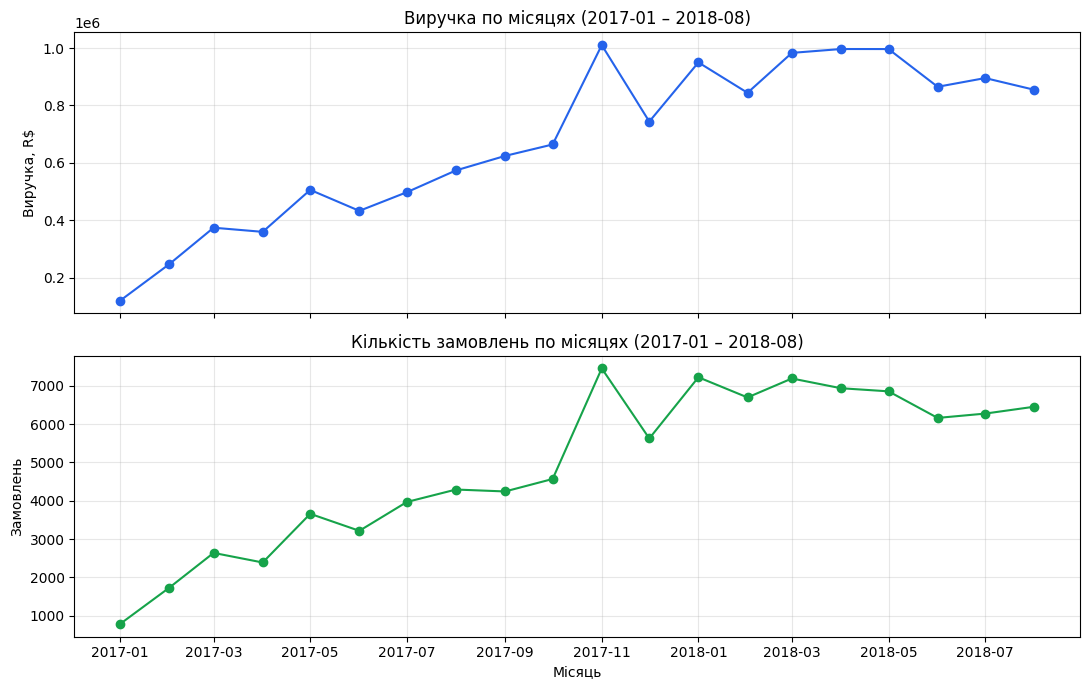

In [4]:
import matplotlib.pyplot as plt

orders = dfs['olist_orders_dataset']
items = dfs['olist_order_items_dataset']

# З'єднуємо товарні позиції з датою покупки із замовлень
rev = items.merge(orders[['order_id', 'order_purchase_timestamp']], on='order_id', how='left')
rev['month'] = rev['order_purchase_timestamp'].dt.to_period('M').dt.to_timestamp()

# Агрегація: виручка та кількість замовлень по місяцях
monthly = rev.groupby('month').agg(
    revenue=('price', 'sum'),
    orders=('order_id', 'nunique')
).reset_index()

# Прибираємо неповні крайні місяці та лишаємо період зі стабільними даними
monthly = monthly[(monthly['month'] >= '2017-01-01') & (monthly['month'] <= '2018-08-01')]

# Два графіки один під одним
fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
axes[0].plot(monthly['month'], monthly['revenue'], color='#2563eb', marker='o')
axes[0].set_title('Виручка по місяцях (2017-01 – 2018-08)')
axes[0].set_ylabel('Виручка, R$')
axes[0].grid(alpha=0.3)
axes[1].plot(monthly['month'], monthly['orders'], color='#16a34a', marker='o')
axes[1].set_title('Кількість замовлень по місяцях (2017-01 – 2018-08)')
axes[1].set_ylabel('Замовлень')
axes[1].set_xlabel('Місяць')
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Висновок (Питання 1):**

- Платформа Olist стрімко зростала протягом 2017 року, від кількох сотень до 6–7 тис. замовлень на місяць.
- Найбільший пік виручки й замовлень припав на листопад 2017 - Чорну п'ятницю, головну сезонну подію для e-commerce.
- У 2018 році продажі вийшли на плато (6–7 тис. замовлень/міс), тобто темп зростання сповільнився.
- Ми свідомо відсікли неповні крайні місяці (кінець 2016 і вересень 2018), щоб тренд був коректним

**Рекомендація:** для коректного аналізу трендів варто відсікати неповні крайні місяці, а бізнесу заздалегідь готувати запаси й маркетинг під сезонні піки (Чорна п'ятниця), бо це найпотужніший драйвер продажів.

### Питання 2. Які категорії товарів дають найбільше виручки та замовлень?

Додаємо до кожної товарної позиції її категорію (з таблиці товарів) та англійську назву категорії (з таблиці-перекладача). Рахуємо сумарну виручку й кількість замовлень по кожній категорії та беремо топ-10.

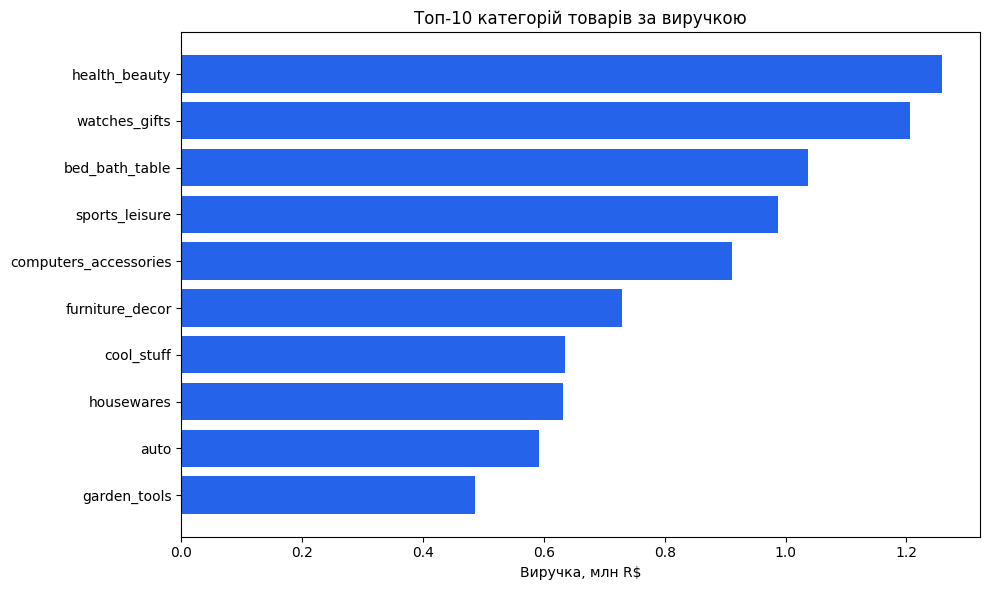

,product_category_name_english,revenue,orders
0,health_beauty,1258681.34,8836
1,watches_gifts,1205005.68,5624
2,bed_bath_table,1036988.68,9417
3,sports_leisure,988048.97,7720
4,computers_accessories,911954.32,6689
5,furniture_decor,729762.49,6449
6,cool_stuff,635290.85,3632
7,housewares,632248.66,5884
8,auto,592720.11,3897
9,garden_tools,485256.46,3518


In [5]:
import matplotlib.pyplot as plt

items = dfs['olist_order_items_dataset']
products = dfs['olist_products_dataset']
translation = dfs['product_category_name_translation']

cat = (items
       .merge(products[['product_id', 'product_category_name']], on='product_id', how='left')
       .merge(translation, on='product_category_name', how='left'))

top_cat = (cat.groupby('product_category_name_english')
           .agg(revenue=('price', 'sum'),
                orders=('order_id', 'nunique'))
           .sort_values('revenue', ascending=False)
           .head(10)
           .reset_index())

# Виручку показуємо в мільйонах R$ — щоб вісь була читабельна (без "1e6")
plt.figure(figsize=(10, 6))
plt.barh(top_cat['product_category_name_english'], top_cat['revenue'] / 1e6, color='#2563eb')
plt.gca().invert_yaxis()
plt.title('Топ-10 категорій товарів за виручкою')
plt.xlabel('Виручка, млн R$')
plt.tight_layout()
plt.show()

top_cat

**Висновок (Питання 2):**

- Найбільшу виручку приносять health_beauty (1.26 млн R$), watches_gifts (1.21 млн) та bed_bath_table (1.04 млн).
- За кількістю замовлень лідирує bed_bath_table (9.4 тис.), а watches_gifts при меншій кількості замовлень (5.6 тис.) все одно в топі за виручкою - це категорія з вищим середнім чеком.
- Отже, лідери за виручкою й за кількістю замовлень не завжди збігаються: одні категорії беруть обсягом, інші вартістю товару.

**Рекомендація:** зосередити асортимент і маркетинг на топ-категоріях; преміальні категорії (watches_gifts) розвивати окремо як джерело високої виручки з меншої кількості продажів.

### Питання 3. Як регіон (штат) впливає на обсяг продажів і середній чек?

Визначаємо штат клієнта для кожного замовлення, рахуємо суму виручки по кожному замовленню, а потім агрегуємо по штатах: загальну виручку, кількість замовлень і середній чек (AOV - average order value).

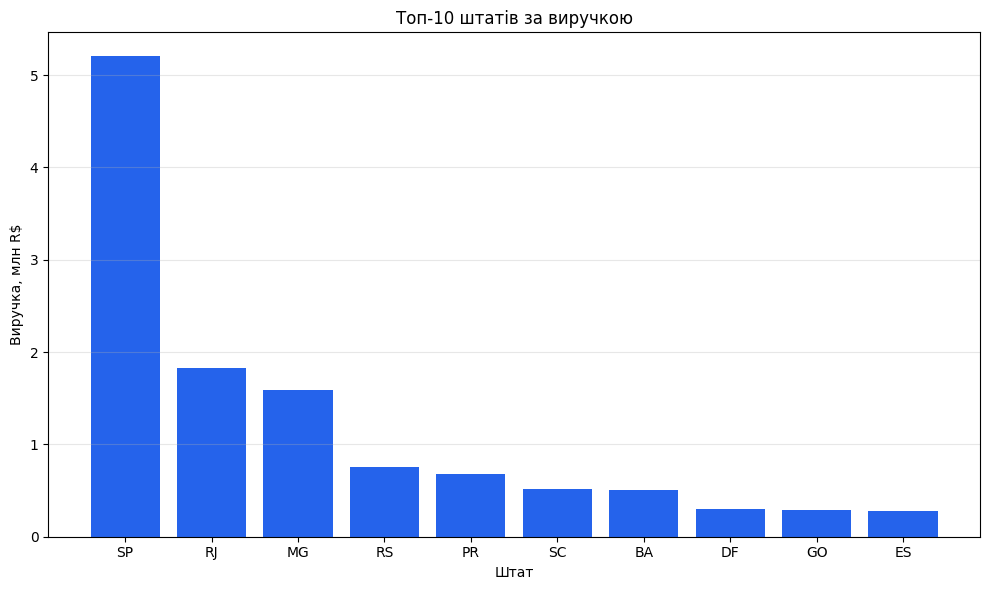

,customer_state,revenue,orders,aov
0,SP,5202955.05,41375,125.75
1,RJ,1824092.67,12762,142.93
2,MG,1585308.03,11544,137.33
3,RS,750304.02,5432,138.13
4,PR,683083.76,4998,136.67
5,SC,520553.34,3612,144.12
6,BA,511349.99,3358,152.28
7,DF,302603.94,2125,142.40
8,GO,294591.95,2007,146.78
9,ES,275037.31,2025,135.82


In [6]:
import matplotlib.pyplot as plt

orders = dfs['olist_orders_dataset']
items = dfs['olist_order_items_dataset']
customers = dfs['olist_customers_dataset']

# Виручка по кожному замовленню (сума цін товарів у замовленні)
order_value = items.groupby('order_id')['price'].sum().reset_index(name='order_revenue')

# Додаємо штат клієнта до кожного замовлення
order_state = (order_value
    .merge(orders[['order_id', 'customer_id']], on='order_id', how='left')
    .merge(customers[['customer_id', 'customer_state']], on='customer_id', how='left'))

# Агрегація по штатах: виручка, к-сть замовлень, середній чек (AOV)
by_state = (order_state.groupby('customer_state')
    .agg(revenue=('order_revenue', 'sum'),
         orders=('order_id', 'count'),
         aov=('order_revenue', 'mean'))
    .sort_values('revenue', ascending=False)
    .reset_index())

# Графік: топ-10 штатів за виручкою
top_states = by_state.head(10)
plt.figure(figsize=(10, 6))
plt.bar(top_states['customer_state'], top_states['revenue'] / 1e6, color='#2563eb')
plt.title('Топ-10 штатів за виручкою')
plt.xlabel('Штат')
plt.ylabel('Виручка, млн R$')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

by_state.head(10).round(2)

**Висновок (Питання 3):**

- Продажі сильно сконцентровані в штаті SP (Сан-Паулу) - близько 5.2 млн реалів і 41 тис. замовлень, більше за всі інші штати разом. Південний схід (SP, RJ, MG) дає основну частку виручки.
- Цікаво, що SP має найнижчий середній чек (близько 126 реалів), тоді як менші штати - вищий: BA 152, GO 147, SC - 144 реали. Тобто найбільший ринок за обсягом не є найціннішим за одне замовлення.
- Ймовірне пояснення: у великому конкурентному ринку SP клієнти роблять частіші, але дрібніші покупки; у віддалених штатах - рідші, зате більші замовлення.

**Рекомендація:** тримати логістику й маркетинг сильними в SP/RJ/MG (основна виручка), але звернути увагу на штати з високим середнім чеком і малим обсягом (BA, GO) - там є потенціал зростання, якщо покращити доступність і доставку.

### Питання 4. Який середній час доставки і як він пов'язаний з оцінками клієнтів?

Рахуємо час доставки (різниця між датою отримання та датою покупки) для доставлених замовлень і дивимось, як він пов'язаний з оцінкою відгуку (1–5).

Середній час доставки: 12.1 днів


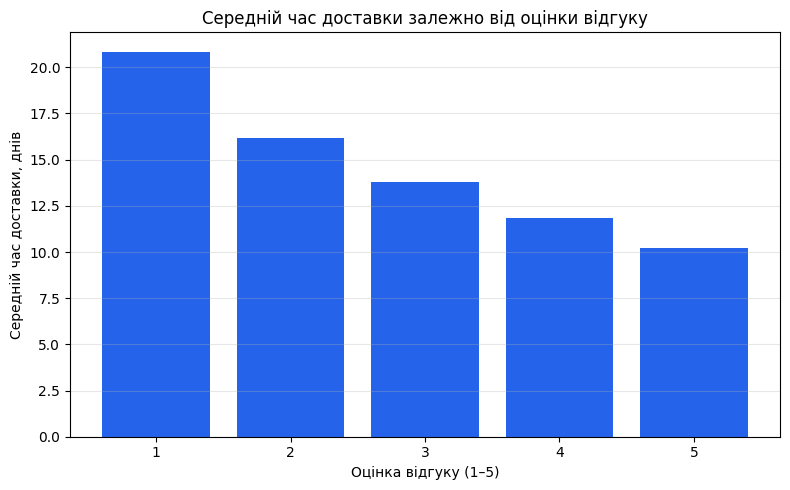

,review_score,delivery_days
0,1,20.8
1,2,16.2
2,3,13.8
3,4,11.8
4,5,10.2


In [7]:
import matplotlib.pyplot as plt

orders = dfs['olist_orders_dataset']
reviews = dfs['olist_order_reviews_dataset']

# Беремо лише доставлені замовлення
delivered = orders[orders['order_status'] == 'delivered'].copy()

# Час доставки в днях = дата отримання - дата покупки
delivered['delivery_days'] = (
    delivered['order_delivered_customer_date'] - delivered['order_purchase_timestamp']
).dt.days

# Додаємо оцінку відгуку
dr = delivered.merge(reviews[['order_id', 'review_score']], on='order_id', how='inner')

# Прибираємо рядки без часу доставки або без оцінки
dr = dr.dropna(subset=['delivery_days', 'review_score'])

print('Середній час доставки:', round(dr['delivery_days'].mean(), 1), 'днів')

# Середній час доставки для кожної оцінки
by_score = dr.groupby('review_score')['delivery_days'].mean().reset_index()

plt.figure(figsize=(8, 5))
plt.bar(by_score['review_score'], by_score['delivery_days'], color='#2563eb')
plt.title('Середній час доставки залежно від оцінки відгуку')
plt.xlabel('Оцінка відгуку (1–5)')
plt.ylabel('Середній час доставки, днів')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

by_score.round(1)

**Висновок (Питання 4):**

- Середній час доставки - близько 12 днів.
- Є чіткий зв'язок між швидкістю доставки та оцінкою: замовлення з оцінкою 1 йшли в середньому 20.8 дня, а з оцінкою 5 - лише 10.2 дня, тобто вдвічі швидше.
- Чим довша доставка, тим нижча оцінка — швидкість доставки є одним із найважливіших драйверів задоволеності клієнтів.

**Рекомендація:** інвестувати у швидшу й передбачуванішу доставку та ставити клієнтам реалістичні очікування щодо термінів - це один із найсильніших важелів для підвищення оцінок і лояльності.

### Питання 5. Які способи оплати найпопулярніші і чи різниться середній чек між ними?

Групуємо платежі за типом оплати й рахуємо кількість транзакцій (популярність) та середній чек для кожного способу.

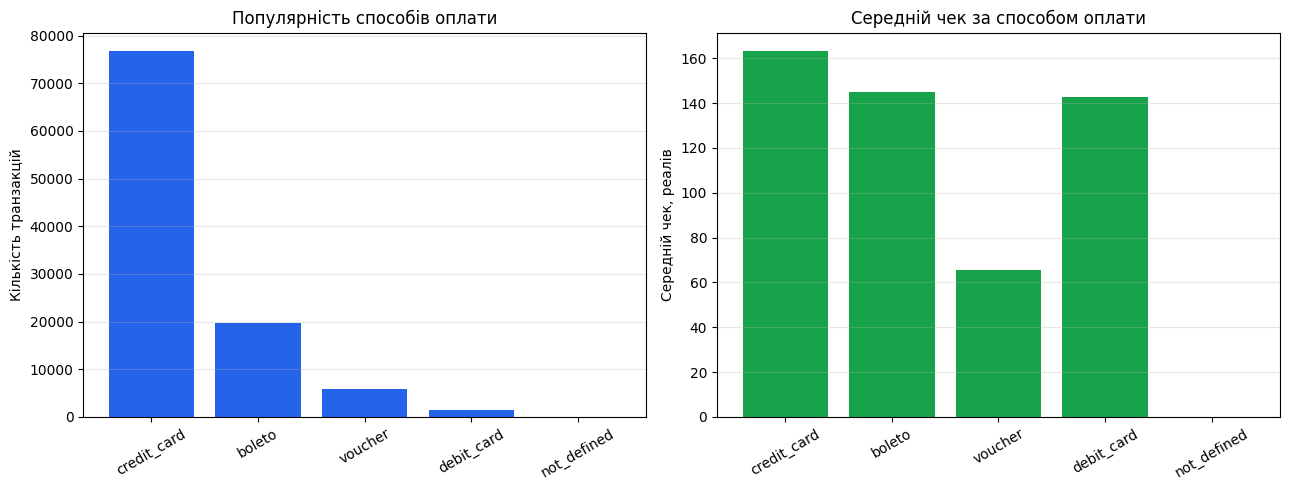

,payment_type,count,avg_value
0,credit_card,76795,163.32
1,boleto,19784,145.03
2,voucher,5775,65.70
3,debit_card,1529,142.57
4,not_defined,3,0.00


In [8]:
import matplotlib.pyplot as plt

payments = dfs['olist_order_payments_dataset']

# Агрегація по способу оплати: кількість транзакцій і середній чек
by_pay = (payments.groupby('payment_type')
          .agg(count=('order_id', 'count'),
               avg_value=('payment_value', 'mean'))
          .sort_values('count', ascending=False)
          .reset_index())

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Популярність (кількість транзакцій)
axes[0].bar(by_pay['payment_type'], by_pay['count'], color='#2563eb')
axes[0].set_title('Популярність способів оплати')
axes[0].set_ylabel('Кількість транзакцій')
axes[0].tick_params(axis='x', rotation=30)
axes[0].grid(axis='y', alpha=0.3)

# Середній чек
axes[1].bar(by_pay['payment_type'], by_pay['avg_value'], color='#16a34a')
axes[1].set_title('Середній чек за способом оплати')
axes[1].set_ylabel('Середній чек, реалів')
axes[1].tick_params(axis='x', rotation=30)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

by_pay.round(2)

**Висновок (Питання 5):**

- Найпопулярніший спосіб оплати - кредитна картка (76.8 тис. транзакцій, 74% усіх). На другому місці boleto (19.8 тис., 19%). Разом вони покривають понад 90% платежів.
- Середній чек також найвищий у кредитної картки (163 реали), далі boleto (~145) і дебетова картка (~143). Найнижчий - у ваучерів (66), бо це зазвичай часткові або невеликі платежі.
- Імовірно, кредитна картка дає вищий чек завдяки розстрочці, яка в Бразилії дозволяє купувати дорожче.

**Рекомендація:** забезпечити максимально зручну оплату карткою (вона несе 3/4 транзакцій і найбільший чек) і підтримувати boleto для клієнтів без картки; розглянути просування розстрочки для збільшення середнього чека.

### Питання 6. Яка частка повторних покупців і як виглядає утримання по когортах?

Спочатку визначаємо, скільки клієнтів роблять повторні покупки. Важливо: справжнього клієнта визначає customer_unique_id (а не customer_id, який у Olist унікальний для кожного замовлення).

Унікальних клієнтів: 96096
Одноразові: 93099 (96.9%)
Повторні: 2997 (3.1%)


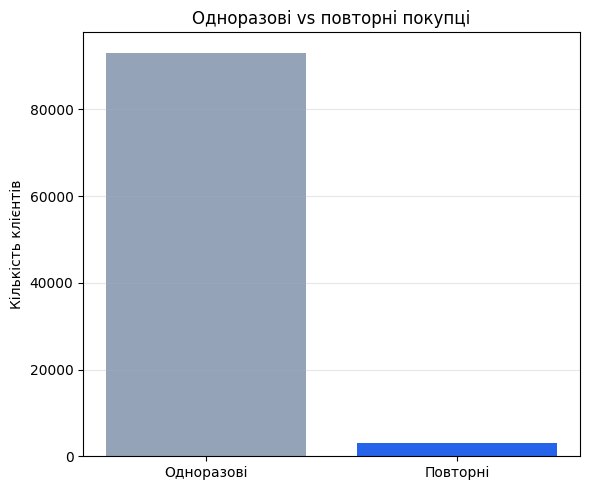

In [9]:
import matplotlib.pyplot as plt

orders = dfs['olist_orders_dataset']
customers = dfs['olist_customers_dataset']

# Приєднуємо справжній ідентифікатор клієнта (customer_unique_id)
orders_cust = orders.merge(
    customers[['customer_id', 'customer_unique_id']], on='customer_id', how='left'
)

# Скільки замовлень зробив кожен клієнт
orders_per_customer = orders_cust.groupby('customer_unique_id')['order_id'].nunique()

# Одноразові vs повторні покупці
one_time = (orders_per_customer == 1).sum()
repeat = (orders_per_customer > 1).sum()
total = one_time + repeat

print(f'Унікальних клієнтів: {total}')
print(f'Одноразові: {one_time} ({one_time/total*100:.1f}%)')
print(f'Повторні: {repeat} ({repeat/total*100:.1f}%)')

plt.figure(figsize=(6, 5))
plt.bar(['Одноразові', 'Повторні'], [one_time, repeat], color=['#94a3b8', '#2563eb'])
plt.title('Одноразові vs повторні покупці')
plt.ylabel('Кількість клієнтів')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

Далі дивимось утримання по когортах: групуємо клієнтів за місяцем першої покупки («когорта») і перевіряємо, який відсоток кожної когорти повертається купувати в наступні місяці.

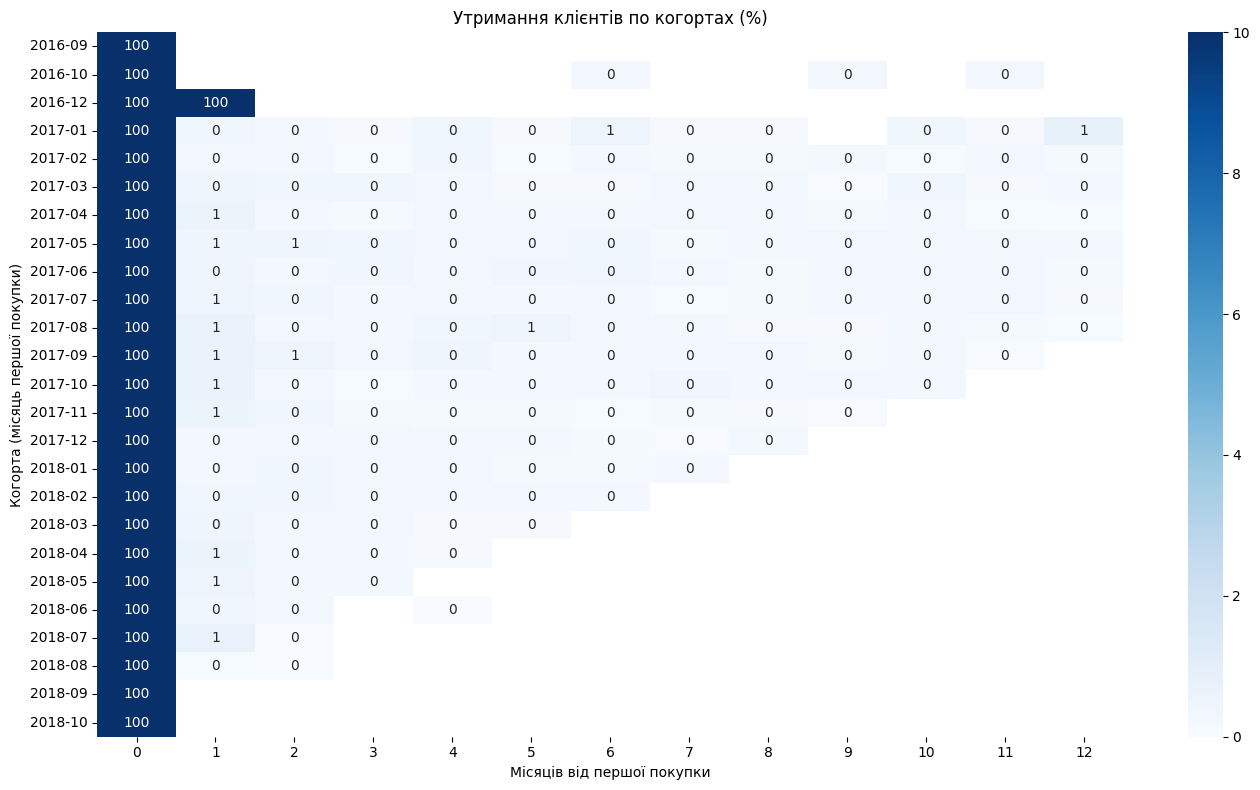

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

orders = dfs['olist_orders_dataset']
customers = dfs['olist_customers_dataset']

# Замовлення з реальним ідентифікатором клієнта і місяцем покупки
oc = orders.merge(customers[['customer_id', 'customer_unique_id']], on='customer_id', how='left').copy()
oc['order_month'] = oc['order_purchase_timestamp'].dt.to_period('M')

# Місяць першої покупки кожного клієнта (його когорта)
first_purchase = oc.groupby('customer_unique_id')['order_month'].min().rename('cohort_month')
oc = oc.merge(first_purchase, on='customer_unique_id', how='left')

# Скільки місяців минуло від першої покупки до цього замовлення
oc['cohort_index'] = ((oc['order_month'].dt.year  - oc['cohort_month'].dt.year) * 12
                      + (oc['order_month'].dt.month - oc['cohort_month'].dt.month))

# Кількість унікальних клієнтів у кожній комірці (когорта × місяць)
cohort_counts = (oc.groupby(['cohort_month', 'cohort_index'])['customer_unique_id']
                 .nunique().reset_index())

# Матриця: рядки — когорта, стовпці — місяць від першої покупки
cohort_pivot = cohort_counts.pivot(index='cohort_month', columns='cohort_index', values='customer_unique_id')

# Утримання у %: ділимо кожен рядок на розмір когорти (місяць 0)
retention = cohort_pivot.divide(cohort_pivot[0], axis=0) * 100

# Теплова карта (перші 13 місяців)
plt.figure(figsize=(14, 8))
sns.heatmap(retention.iloc[:, :13], annot=True, fmt='.0f', cmap='Blues', vmin=0, vmax=10)
plt.title('Утримання клієнтів по когортах (%)')
plt.xlabel('Місяців від першої покупки')
plt.ylabel('Когорта (місяць першої покупки)')
plt.tight_layout()
plt.show()

**Висновок (Питання 6):**

- Лише 3.1% клієнтів роблять повторну покупку - 96.9% купують лише раз.
- Теплова карта когорт підтверджує: після місяця першої покупки (100%) утримання падає майже до 0–1% у всіх наступних місяцях для кожної когорти. Регулярних повторних покупок практично немає.
- (Значення 100% у когорті 2016-12 - це шум через дуже малу когорту в перші місяці роботи платформи, а не реальний патерн.)
- Olist працює фактично як майданчик «однієї покупки»: цінність клієнта дорівнює одному замовленню.

**Рекомендація:** утримання - найбільший невикористаний резерв зростання. Навіть невелике підвищення частки повторних покупок суттєво збільшить виручку. Варто впровадити пост-продажну комунікацію (email, програма лояльності, знижка на друге замовлення), персональні рекомендації та покращення доставки - адже саме вона (Питання 4) найсильніше впливає на задоволеність.

### Питання 7. Чи є статистично значуща різниця в оцінках між швидкою й повільною доставкою?

Ділимо замовлення на дві групи за медіаною часу доставки (швидка / повільна) і перевіряємо t-тестом, чи різниця в середніх оцінках статистично значуща, а не випадкова.

Медіана часу доставки: 10 днів
Швидка доставка: 52079 замовлень, середня оцінка 4.38
Повільна доставка: 44274 замовлень, середня оцінка 3.89

t-статистика: 58.2
p-значення: 0.00e+00

Різниця СТАТИСТИЧНО ЗНАЧУЩА (p < 0.05): швидша доставка пов'язана з вищими оцінками.


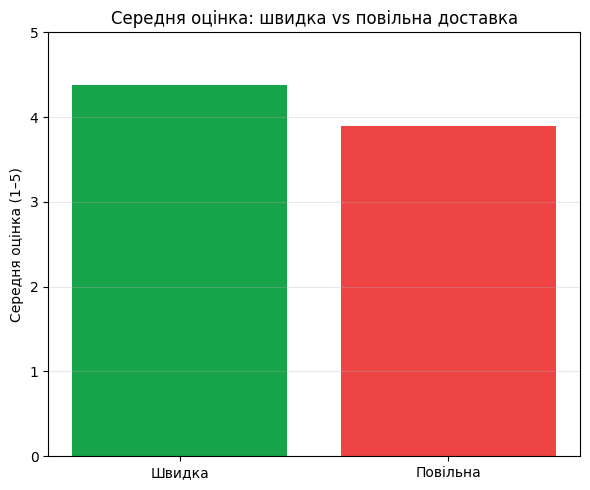

In [11]:
from scipy import stats
import matplotlib.pyplot as plt

orders = dfs['olist_orders_dataset']
reviews = dfs['olist_order_reviews_dataset']

# Готуємо дані: час доставки + оцінка
delivered = orders[orders['order_status'] == 'delivered'].copy()
delivered['delivery_days'] = (
    delivered['order_delivered_customer_date'] - delivered['order_purchase_timestamp']
).dt.days
dr = delivered.merge(reviews[['order_id', 'review_score']], on='order_id', how='inner')
dr = dr.dropna(subset=['delivery_days', 'review_score'])

# Дві групи за медіаною часу доставки
median_days = dr['delivery_days'].median()
fast = dr[dr['delivery_days'] <= median_days]['review_score']
slow = dr[dr['delivery_days'] >  median_days]['review_score']

print(f'Медіана часу доставки: {median_days:.0f} днів')
print(f'Швидка доставка: {len(fast)} замовлень, середня оцінка {fast.mean():.2f}')
print(f'Повільна доставка: {len(slow)} замовлень, середня оцінка {slow.mean():.2f}')

# t-тест
t_stat, p_value = stats.ttest_ind(fast, slow, equal_var=False)
print(f'\nt-статистика: {t_stat:.1f}')
print(f'p-значення: {p_value:.2e}')

if p_value < 0.05:
    print("\nРізниця СТАТИСТИЧНО ЗНАЧУЩА (p < 0.05): швидша доставка пов'язана з вищими оцінками.")
else:
    print("\nРізниця не є статистично значущою (p >= 0.05).")

# Візуалізація
plt.figure(figsize=(6, 5))
plt.bar(['Швидка', 'Повільна'], [fast.mean(), slow.mean()], color=['#16a34a', '#ef4444'])
plt.title('Середня оцінка: швидка vs повільна доставка')
plt.ylabel('Середня оцінка (1–5)')
plt.ylim(0, 5)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

**Висновок (Питання 7):**

- Замовлення зі швидкою доставкою (≤10 днів) мають середню оцінку 4.38, а з повільною (>10 днів) - 3.89, майже на пів зірки нижче.
- t-тест дав t = 58.2 і p ≈ 0 (значно менше за 0.05), тож різниця статистично значуща - це не випадковість.
- Це строго підтверджує висновок Питання 4: швидкість доставки реально впливає на задоволеність.
- (Зауваження: на великій вибірці майже будь-яка різниця стає «значущою», тому дивимось і на її розмір - пів зірки на шкалі 1–5 це суттєво.)

**Рекомендація:** оскільки зв'язок підтверджено статистично, прискорення доставки - це обґрунтований даними важіль для підвищення оцінок (а отже й потенційно утримання клієнтів).

### Питання 8. Які фактори найбільше корелюють з негативними відгуками?

Збираємо числові ознаки кожного замовлення (час доставки, запізнення проти обіцяної дати, вартість доставки, сума замовлення, кількість позицій) і рахуємо їхню кореляцію з оцінкою відгуку (метод Пірсона). Чим більший за модулем коефіцієнт - тим сильніший зв'язок; від'ємний означає, що зростання фактора знижує оцінку.

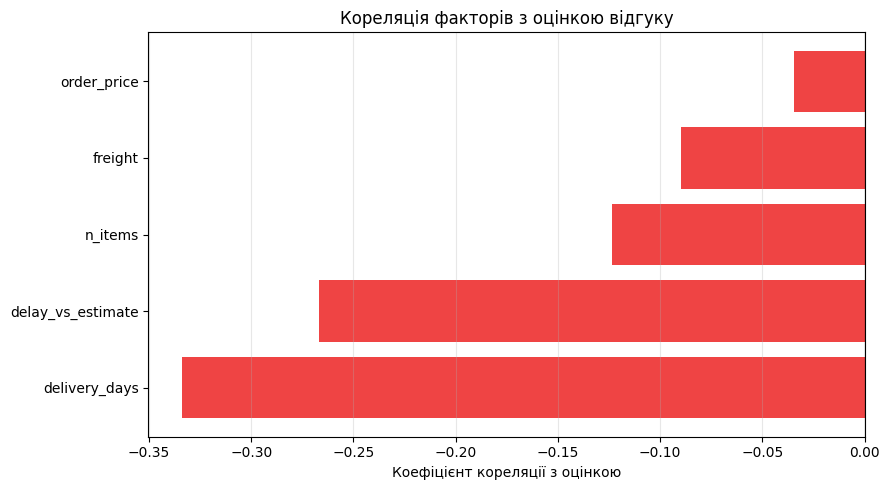

,review_score
delivery_days,-0.334
delay_vs_estimate,-0.267
n_items,-0.123
freight,-0.090
order_price,-0.035


In [12]:
import matplotlib.pyplot as plt

orders = dfs['olist_orders_dataset']
items = dfs['olist_order_items_dataset']
reviews = dfs['olist_order_reviews_dataset']

# Ознаки на рівні замовлення
delivered = orders[orders['order_status'] == 'delivered'].copy()
delivered['delivery_days'] = (delivered['order_delivered_customer_date'] - delivered['order_purchase_timestamp']).dt.days
delivered['delay_vs_estimate'] = (delivered['order_delivered_customer_date'] - delivered['order_estimated_delivery_date']).dt.days

# Сума ціни, доставки та кількість позицій по замовленню
order_feats = items.groupby('order_id').agg(
    order_price=('price', 'sum'),
    freight=('freight_value', 'sum'),
    n_items=('order_item_id', 'count')
).reset_index()

# Збираємо все разом + оцінка
df = (delivered[['order_id', 'delivery_days', 'delay_vs_estimate']]
      .merge(order_feats, on='order_id', how='left')
      .merge(reviews[['order_id', 'review_score']], on='order_id', how='inner')
      .dropna())

# Кореляція кожної ознаки з оцінкою
corr = (df[['delivery_days', 'delay_vs_estimate', 'freight', 'order_price', 'n_items', 'review_score']]
        .corr()['review_score'].drop('review_score').sort_values())

plt.figure(figsize=(9, 5))
colors = ['#ef4444' if c < 0 else '#16a34a' for c in corr]
plt.barh(corr.index, corr.values, color=colors)
plt.title('Кореляція факторів з оцінкою відгуку')
plt.xlabel('Коефіцієнт кореляції з оцінкою')
plt.axvline(0, color='black', linewidth=0.8)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

corr.round(3)

**Висновок (Питання 8):**

- Найсильніше з негативними відгуками пов'язані фактори доставки: загальний час доставки (кореляція -0.33) і запізнення проти обіцяної дати (-0.27).
- Кількість позицій (-0.12) і вартість доставки (-0.09) впливають помірно, а сума замовлення майже не впливає (-0.03) - клієнти не оцінюють покупку за її ціною.
- Усі зв'язки помірні за силою, тобто доставка пояснює частину незадоволеності, але не все - є й інші фактори (якість товару, очікування), яких немає в цих даних.

**Рекомендація:** головний фокус - доставка: і швидкість, і дотримання обіцяних термінів. Варто ставити реалістичні дати й випереджати їх, бо запізнення проти обіцянки б'є по оцінках майже так само сильно, як і повільна доставка.

## 4. Загальні висновки та рекомендації

**Ключові висновки:**

1. **Зростання й сезонність.** Olist стрімко зростав у 2017 році й вийшов на плато (6–7 тис. замовлень/міс) у 2018. Найбільший пік - Чорна п'ятниця (листопад 2017).
2. **Асортимент.** Основну виручку дають health_beauty, watches_gifts і bed_bath_table. Одні категорії беруть обсягом, інші - вищим середнім чеком.
3. **Географія.** Продажі сконцентровані в SP, RJ, MG, причому SP домінує за обсягом, але має найнижчий середній чек.
4. **Доставка - головний драйвер задоволеності.** Час доставки й запізнення проти обіцяної дати найсильніше пов'язані з низькими оцінками; t-тест підтвердив, що різниця між швидкою й повільною доставкою статистично значуща.
5. **Найбільша слабкість - утримання.** Лише 3% клієнтів повертаються; платформа працює як майданчик «однієї покупки».

**Головні рекомендації:**

1. Інвестувати в доставку - і швидкість, і дотримання обіцяних термінів.
2. Запустити програму утримання (пост-продажна комунікація, лояльність, знижка на друге замовлення).
3. Готуватися до сезонних піків (Чорна п'ятниця) заздалегідь.
4. Розвивати топ і преміальні категорії та регіони з високим середнім чеком.